### 15. I avsnitt 4.4.1 "Kodexempel 1 - Klassificering av MNIST" modelleras *MNIST*. Skriv kod så att du kan ta egna bilder (via exempelvis mobilen) på handskrivna siffror och prediktera dessa. Om du känner dig inspirerad kan du också skapa en *Streamlit* applikation. Notera, det huvudsakliga arbetet blir alltså att *preprocessa*, det vill säga bearbeta bilderna som tas via mobilen så modellen kan prediktera dem. I verkligheten är det ofta långt ifrån trivialt att genomföra *preprocessing*. Exempel på hur denna typ av projekt kan se ut kan du se här: [https://www.linkedin.com/posts/antonioprgomet_toppresultat-fr%C3%A5n-deltagarna-p%C3%A5-kursen-pythonprogrammering-activity-7292893718028718081-oAD0?utm_source=share&utm_medium=member_desktop&rcm=ACoAADH7YOkBJcbaNUfHDmlA4-6mf94mMwPgnRk](https://www.linkedin.com/posts/antonioprgomet_toppresultat-fr%C3%A5n-deltagarna-p%C3%A5-kursen-pythonprogrammering-activity-7292893718028718081-oAD0?utm_source=share&utm_medium=member_desktop&rcm=ACoAADH7YOkBJcbaNUfHDmlA4-6mf94mMwPgnRk)


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)

In [3]:
def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()

In [4]:
mnist = fetch_openml("mnist_784", version=1, cache=True, as_frame=False)
X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)

print(X.shape)
print(y.shape)

(10000, 784)
(10000,)


True label for the pltoted image is 0


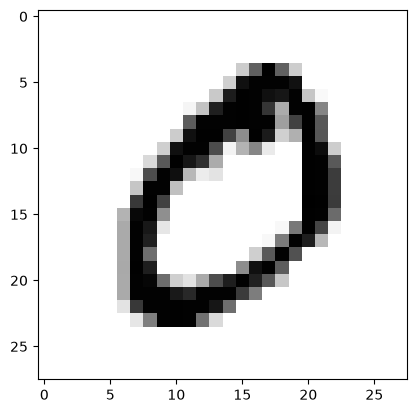

In [5]:
some_digit = X[1]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the pltoted image is", y[1])

In [6]:
# Splitting data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=2000, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=2000, random_state=42
)

# Scaling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# Model training
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf),
]
voting_clf = VotingClassifier(named_estimators, voting="hard")

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]
for model in models:
    model.fit(X_train, y_train)

print("Accuracy for each model")
model_names = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "Voting Classifier",
]

for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name:20s}: {score:.4f}")

Accuracy for each model
Logistic Regression : 0.8800
Random Forest       : 0.9375
Extra Trees         : 0.9410
Voting Classifier   : 0.9410


              precision    recall  f1-score   support

           0       0.97      0.98      0.97       217
           1       0.99      0.98      0.98       217
           2       0.93      0.91      0.92       190
           3       0.95      0.89      0.92       218
           4       0.95      0.92      0.93       215
           5       0.95      0.90      0.92       160
           6       0.95      0.98      0.97       197
           7       0.94      0.93      0.94       210
           8       0.92      0.96      0.94       183
           9       0.87      0.95      0.91       193

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



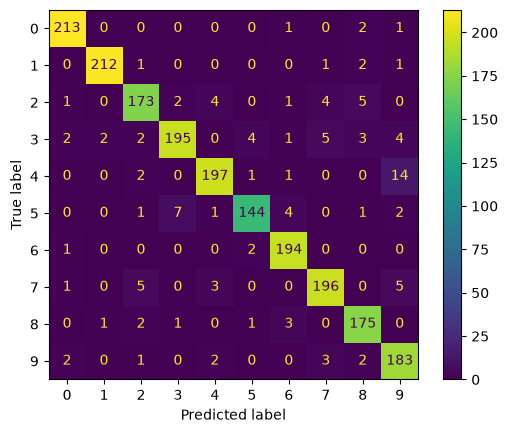

In [8]:
et_pred_val = extra_trees_clf.predict(X_val)

display_confusion_matrix(y_val, et_pred_val)
print(classification_report(y_val, et_pred_val))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       207
           1       0.97      0.99      0.98       216
           2       0.96      0.96      0.96       204
           3       0.93      0.92      0.92       192
           4       0.97      0.96      0.96       211
           5       0.96      0.92      0.94       176
           6       0.98      0.98      0.98       220
           7       0.96      0.97      0.97       216
           8       0.95      0.95      0.95       166
           9       0.94      0.92      0.93       192

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



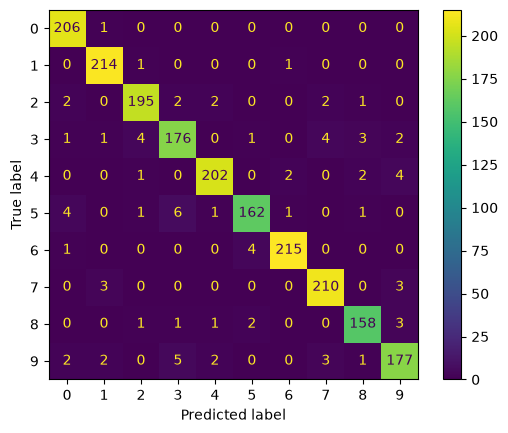

In [9]:
# Refit model on train + validation data
X_train_val = scaler.fit_transform(X_train_val)
extra_trees_clf.fit(X_train_val, y_train_val)

# Evaluate it on test data
et_pred_test = extra_trees_clf.predict(X_test)
display_confusion_matrix(y_test, et_pred_test)
print(classification_report(y_test, et_pred_test))

In [10]:
scaler_2 = StandardScaler()
X = scaler_2.fit_transform(X)
extra_trees_clf.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` 

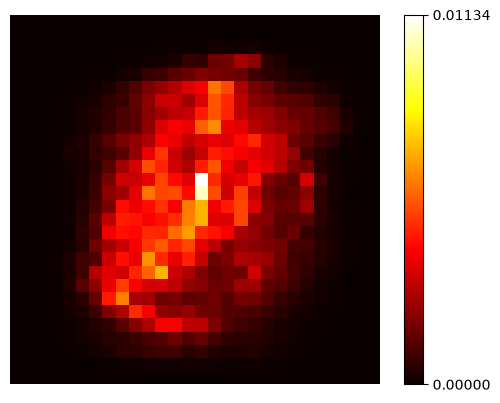

In [11]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.hot, interpolation="nearest")
    plt.axis("off")


plot_digit(extra_trees_clf.feature_importances_)

cbar = plt.colorbar(
    ticks=[
        extra_trees_clf.feature_importances_.min(),
        extra_trees_clf.feature_importances_.max(),
    ]
)

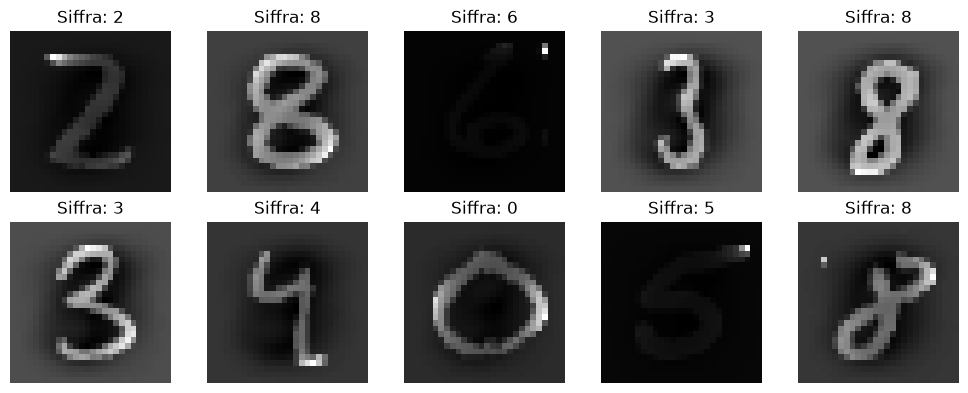

In [12]:
# Visualisera några bilder och prediktioner
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image = X_test[i].reshape(28, 28)
    pred = extra_trees_clf.predict([X_test[i]])[0]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Siffra: {pred}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
from PIL import Image
import numpy as np

# Ladda din egen bild
img = Image.open("../../data/nummer4.png")

# Gör den gråskala
img = img.convert("L")

img = img.resize((28, 28))

img_array = np.array(img).astype(np.float64)

img_array = 255 - img_array

img_flat = img_array.reshape(1, -1)

img_scaled = scaler_2.transform(img_flat)

prediction = extra_trees_clf.predict(img_scaled)
print(f"Modellen tror det är siffran: {prediction[0]}")

print(classification_report(y_val, et_pred_val))

Modellen tror det är siffran: 8
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       217
           1       0.99      0.98      0.98       217
           2       0.93      0.91      0.92       190
           3       0.95      0.89      0.92       218
           4       0.95      0.92      0.93       215
           5       0.95      0.90      0.92       160
           6       0.95      0.98      0.97       197
           7       0.94      0.93      0.94       210
           8       0.92      0.96      0.94       183
           9       0.87      0.95      0.91       193

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [14]:
os.makedirs("streamlit_app/models", exist_ok=True)

joblib.dump(extra_trees_clf, "streamlit_app/models/mnist_model.pkl")
joblib.dump(scaler_2, "streamlit_app/models/mnist_scaler.pkl")

print("Modell och scaler sparade!")

Modell och scaler sparade!
